# Modeling Organic Search Performance:
## From Rule-Based Ranking to an Evidence-Supported Candidate Model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShubhamSnSharma/flyrank-ml-internship/blob/main/work/notebooks/w05_final_modeling_journey.ipynb)

**Author:** Shubham Sharma | Machine Learning Engineering Intern  
**Task ID:** ML-08 Capstone Modeling Lane  
**Question Investigated:** *How did this project evolve from a handwritten heuristic rule into an evidence-supported predictive model? Did algorithm selection or feature engineering produce larger measured improvements in Precision@50?*

---

### Project Context & Methodology
This notebook documents the complete modeling investigation for FlyRank's organic search decay system. Rather than optimizing blindly for a leaderboard score, we evaluate the predictive behavior of five algorithm families across two feature representations using empirical evidence.

To ensure scientific fairness and prevent data leakage, every experiment in this notebook uses identical evaluation conditions:
- **Data Source:** DuckDB query over `fact_content_daily_performance` ($N = 16,513$ eligible pages across 36 enterprise clients).
- **Feature Window:** Feb 1 – Apr 30, 2026 (90-day history).
- **Target Window:** May 1 – May 31, 2026 (`is_declining_label = May clicks < 0.80 * April clicks`).
- **Eligibility Criteria:** Feb–Apr impressions $\ge 1000$ AND April clicks $\ge 10$.
- **Validation Strategy:** Client-aware `GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)` on `client_hash_id` (28 train clients, 8 test clients).
- **Evaluation Metric:** `Precision@50` evaluated on held-out test pages using deterministic `content_hash_id` secondary tie-breaking.

The cell below sets up the environment, imports required libraries, and connects to the FlyRank warehouse via DuckDB.

In [1]:
# -------------------------------------------------------------------------
# Cell 1: Environment Setup & Data Connections
# -------------------------------------------------------------------------
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from getpass import getpass
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
from sklearn.inspection import permutation_importance

token = getpass("Enter your Hugging Face READ token: ")
con = duckdb.connect()
con.execute(f"CREATE SECRET IF NOT EXISTS hf_token_secret (TYPE HUGGINGFACE, TOKEN '{token}');")
rel = "hf://datasets/FlyRank/internship-warehouse"

Enter your Hugging Face READ token: ··········


## 1. Feature Representations & Data Leakage Audit

We audit every feature to verify that feature values could exist at prediction time without using future target information.

### Historical Window Boundaries
- **Feature Window:** Feb 1 – Apr 30, 2026 (Partitions `2026-02`, `2026-03`, `2026-04`).
- **Decision Point:** April 30, 2026 at 23:59:59.
- **Target Window:** May 1 – May 31, 2026 (Partition `2026-05`).

### Feature Definitions
1. `log_gsc_impressions_feb_apr`: $\log(1 + \text{Impressions}_{\text{Feb--Apr}})$. Uses only Feb–Apr facts.
2. `log_gsc_clicks_apr`: $\log(1 + \text{Clicks}_{\text{Apr}})$. Uses only April facts.
3. `gsc_avg_position_apr`: $\text{Mean}(\text{Position}_{\text{Apr}})$. Uses only April facts.
4. `pos_delta`: $\text{Position}_{\text{Apr}} - \text{Mean}(\text{Position}_{\text{Feb--Mar}})$. Measures rank shift strictly within historical data.
5. `ctr_delta`: $\text{CTR}_{\text{Apr}} - \text{CTR}_{\text{Feb--Mar}}$. Measures click-through rate shift strictly within historical data.
6. `impr_ratio_apr_vs_feb_mar`: $\text{Impressions}_{\text{Apr}} / ((\text{Impressions}_{\text{Feb--Mar}} / 2) + 1)$. Measures search demand trend within historical data.
7. `pv_ratio_apr_vs_feb_mar`: $\text{Pageviews}_{\text{Apr}} / ((\text{Pageviews}_{\text{Feb--Mar}} / 2) + 1)$. Measures GA4 engagement trend within historical data.

**Leakage Audit Verification:** Zero May 2026 facts (`month = '2026-05'`) are included in any feature column $X$. Target $y$ is computed strictly from May 2026 clicks.

The next cell extracts raw daily performance facts from parquet storage, aggregates them to the page level, computes static and trajectory features, and defines the supervised binary target.

In [2]:
# -------------------------------------------------------------------------
# Cell 2: Data Extraction & Pipeline Execution
# -------------------------------------------------------------------------
modeling_df = con.sql(f"""
WITH daily_facts AS (
    SELECT
        client_hash_id,
        content_hash_id,
        month,
        COALESCE(gsc_impressions, 0) AS gsc_impressions,
        COALESCE(gsc_clicks, 0) AS gsc_clicks,
        gsc_avg_position,
        COALESCE(ga4_pageviews, 0) AS ga4_pageviews,
        COALESCE(ga4_engaged_sessions, 0) AS ga4_engaged_sessions,
        COALESCE(client_has_gsc, FALSE) AS client_has_gsc,
        COALESCE(client_has_ga4, FALSE) AS client_has_ga4,
        COALESCE(gsc_data_available, FALSE) AS gsc_data_available,
        COALESCE(ga4_data_available, FALSE) AS ga4_data_available
    FROM read_parquet(
        '{rel}/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month IN ('2026-02', '2026-03', '2026-04', '2026-05')
),
aggregated_pages AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(CASE WHEN month IN ('2026-02', '2026-03', '2026-04') THEN gsc_impressions ELSE 0 END) AS gsc_impressions_feb_apr,
        SUM(CASE WHEN month IN ('2026-02', '2026-03') THEN gsc_impressions ELSE 0 END) AS gsc_impressions_feb_mar,
        SUM(CASE WHEN month = '2026-04' THEN gsc_impressions ELSE 0 END) AS gsc_impressions_apr,

        SUM(CASE WHEN month IN ('2026-02', '2026-03', '2026-04') THEN gsc_clicks ELSE 0 END) AS gsc_clicks_feb_apr,
        SUM(CASE WHEN month IN ('2026-02', '2026-03') THEN gsc_clicks ELSE 0 END) AS gsc_clicks_feb_mar,
        SUM(CASE WHEN month = '2026-04' THEN gsc_clicks ELSE 0 END) AS gsc_clicks_apr,

        AVG(CASE WHEN month IN ('2026-02', '2026-03') THEN gsc_avg_position ELSE NULL END) AS gsc_avg_pos_feb_mar,
        AVG(CASE WHEN month = '2026-04' THEN gsc_avg_position ELSE NULL END) AS gsc_avg_position_apr,

        SUM(CASE WHEN month IN ('2026-02', '2026-03', '2026-04') THEN ga4_pageviews ELSE 0 END) AS ga4_pageviews_feb_apr,
        SUM(CASE WHEN month IN ('2026-02', '2026-03') THEN ga4_pageviews ELSE 0 END) AS ga4_pageviews_feb_mar,
        SUM(CASE WHEN month = '2026-04' THEN ga4_pageviews ELSE 0 END) AS ga4_pageviews_apr,

        SUM(CASE WHEN month IN ('2026-02', '2026-03', '2026-04') THEN ga4_engaged_sessions ELSE 0 END) AS ga4_engaged_sessions_feb_apr,

        MAX(client_has_gsc) AS client_has_gsc,
        MAX(client_has_ga4) AS client_has_ga4,
        MAX(gsc_data_available) AS gsc_data_available,
        MAX(ga4_data_available) AS ga4_data_available,

        SUM(CASE WHEN month = '2026-05' THEN gsc_clicks ELSE 0 END) AS gsc_clicks_may
    FROM daily_facts
    GROUP BY client_hash_id, content_hash_id
)
SELECT *
FROM aggregated_pages
WHERE gsc_impressions_feb_apr >= 1000
  AND gsc_clicks_apr >= 10
""").df()

# Supervised Target
modeling_df["is_declining_label"] = (
    modeling_df["gsc_clicks_may"] < (0.80 * modeling_df["gsc_clicks_apr"])
).astype(int)
modeling_df["gsc_avg_position_apr"] = modeling_df["gsc_avg_position_apr"].fillna(0.0)
modeling_df["gsc_avg_pos_feb_mar"] = modeling_df["gsc_avg_pos_feb_mar"].fillna(0.0)

# Representation A: Static Totals
modeling_df["log_gsc_impressions_feb_apr"] = np.log1p(modeling_df["gsc_impressions_feb_apr"])
modeling_df["log_gsc_clicks_apr"] = np.log1p(modeling_df["gsc_clicks_apr"])
modeling_df["log_ga4_pageviews_feb_apr"] = np.log1p(modeling_df["ga4_pageviews_feb_apr"])
modeling_df["log_ga4_engaged_sessions_feb_apr"] = np.log1p(modeling_df["ga4_engaged_sessions_feb_apr"])

static_cols = [
    "log_gsc_impressions_feb_apr",
    "log_gsc_clicks_apr",
    "gsc_avg_position_apr",
    "log_ga4_pageviews_feb_apr",
    "log_ga4_engaged_sessions_feb_apr",
    "client_has_gsc",
    "client_has_ga4",
    "gsc_data_available",
    "ga4_data_available",
]

# Representation B: Historical Trajectory & Momentum Ratios
modeling_df["ctr_apr"] = modeling_df["gsc_clicks_apr"] / (modeling_df["gsc_impressions_apr"] + 1.0)
modeling_df["ctr_feb_mar"] = modeling_df["gsc_clicks_feb_mar"] / (modeling_df["gsc_impressions_feb_mar"] + 1.0)
modeling_df["ctr_delta"] = modeling_df["ctr_apr"] - modeling_df["ctr_feb_mar"]

modeling_df["click_ratio_apr_vs_feb_mar"] = modeling_df["gsc_clicks_apr"] / ((modeling_df["gsc_clicks_feb_mar"] / 2.0) + 1.0)
modeling_df["impr_ratio_apr_vs_feb_mar"] = modeling_df["gsc_impressions_apr"] / ((modeling_df["gsc_impressions_feb_mar"] / 2.0) + 1.0)
modeling_df["pos_delta"] = modeling_df["gsc_avg_position_apr"] - modeling_df["gsc_avg_pos_feb_mar"]
modeling_df["pv_ratio_apr_vs_feb_mar"] = modeling_df["ga4_pageviews_apr"] / ((modeling_df["ga4_pageviews_feb_mar"] / 2.0) + 1.0)

trajectory_cols = static_cols + [
    "ctr_apr",
    "ctr_delta",
    "click_ratio_apr_vs_feb_mar",
    "impr_ratio_apr_vs_feb_mar",
    "pos_delta",
    "pv_ratio_apr_vs_feb_mar"
]

y = modeling_df["is_declining_label"].astype(int)
groups = modeling_df["client_hash_id"].astype(str)

# Merge W4 Baseline Score
baseline_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    AVG(
        (
            CASE WHEN COALESCE(gsc_impressions,0) >= 10 THEN 1 ELSE 0 END +
            CASE WHEN gsc_avg_position > 10 THEN 1 ELSE 0 END +
            CASE WHEN COALESCE(ga4_pageviews,0) >= 1 THEN 1 ELSE 0 END
        )
    ) AS baseline_score
FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')
WHERE month = '2026-04'
GROUP BY client_hash_id, content_hash_id
""").df()

modeling_df = modeling_df.merge(baseline_df, on=["client_hash_id", "content_hash_id"], how="left")
modeling_df["baseline_score"] = modeling_df["baseline_score"].fillna(0.0)

print(f"Extracted N={len(modeling_df):,} eligible pages across {modeling_df['client_hash_id'].nunique()} enterprise clients.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Extracted N=16,513 eligible pages across 36 enterprise clients.


## 2. Model Selection Rationale

We started with Logistic Regression because it is simple, easy to interpret, and provides a fair linear baseline against the handwritten Week 4 rule. If a simple linear model could not improve on the baseline, there would be little reason to explore more complex models.

Each evaluated algorithm family serves a specific engineering purpose:
1. **Week 4 Heuristic Rule:** Operational handwritten baseline established via daily thresholding.
2. **Logistic Regression:** Transparent linear log-odds baseline (`StandardScaler` + L2 penalty). Tests whether continuous linear volume weighting improves upon unweighted heuristics.
3. **Decision Tree:** Simplest non-linear interpretable learner (`max_depth=6`, `min_samples_leaf=20`). Tests whether step-function splits (e.g. search position rank cuts) outperform linear hyperplanes.
4. **Random Forest:** Bagging ensemble (100 trees). Tests whether bootstrap aggregation reduces variance and improves probability calibration.
5. **Gradient Boosting:** Sequential boosted ensemble (150 trees, `learning_rate=0.03`). Tests whether residual optimization refines top-K ranking boundaries.

The next cell trains every model family under identical validation conditions and compiles the unified model comparison matrix.

In [3]:
# -------------------------------------------------------------------------
# Cell 3: Unified Comparison Matrix Execution
# -------------------------------------------------------------------------
def precision_at_k(y_true, scores, tie_breakers, k=50):
    eval_df = pd.DataFrame({"y": list(y_true), "score": list(scores), "tie_breaker": list(tie_breakers)})
    top_k = eval_df.sort_values(["score", "tie_breaker"], ascending=[False, True]).head(min(k, len(eval_df)))
    return float(top_k["y"].mean()), int(top_k["y"].sum()), int((top_k["y"] == 0).sum())

gss_42 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_42, te_42 = next(gss_42.split(modeling_df, y, groups=groups))

y_tr, y_te = y.iloc[tr_42], y.iloc[te_42]
ids_te = modeling_df["content_hash_id"].iloc[te_42]

X_static_tr, X_static_te = modeling_df[static_cols].iloc[tr_42].astype(float), modeling_df[static_cols].iloc[te_42].astype(float)
X_traj_tr, X_traj_te = modeling_df[trajectory_cols].iloc[tr_42].astype(float), modeling_df[trajectory_cols].iloc[te_42].astype(float)

# Baseline
base_p50, base_tp, base_fp = precision_at_k(y_te, modeling_df["baseline_score"].iloc[te_42], ids_te, k=50)

comparison_rows = [
    {
        "Model": "Week 4 Heuristic Rule",
        "Feature Set": "3-Signal Daily Rule",
        "Precision@50": f"{base_p50:.4f}",
        "TP@50": base_tp,
        "FP@50": base_fp,
        "Reason for Inclusion": "Operational handwritten heuristic baseline",
        "Interpretability": "High (Handwritten Rule)",
        "Training Acc": "N/A",
        "Testing Acc": "N/A"
    }
]

# LR Static
lr_static = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))])
lr_static.fit(X_static_tr, y_tr)
p_lr_s = lr_static.predict_proba(X_static_te)[:, 1]
p50_lr_s, tp_lr_s, fp_lr_s = precision_at_k(y_te, p_lr_s, ids_te, k=50)
comparison_rows.append({
    "Model": "Logistic Regression",
    "Feature Set": "Static Totals",
    "Precision@50": f"{p50_lr_s:.4f}",
    "TP@50": tp_lr_s,
    "FP@50": fp_lr_s,
    "Reason for Inclusion": "Transparent interpretable linear baseline",
    "Interpretability": "High (Linear Log-Odds)",
    "Training Acc": f"{accuracy_score(y_tr, lr_static.predict(X_static_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, lr_static.predict(X_static_te)):.4f}"
})

# LR Trajectory
lr_traj = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))])
lr_traj.fit(X_traj_tr, y_tr)
p_lr_t = lr_traj.predict_proba(X_traj_te)[:, 1]
p50_lr_t, tp_lr_t, fp_lr_t = precision_at_k(y_te, p_lr_t, ids_te, k=50)
comparison_rows.append({
    "Model": "Logistic Regression",
    "Feature Set": "Trajectory & Ratios",
    "Precision@50": f"{p50_lr_t:.4f}",
    "TP@50": tp_lr_t,
    "FP@50": fp_lr_t,
    "Reason for Inclusion": "Transparent interpretable linear baseline",
    "Interpretability": "High (Linear Log-Odds)",
    "Training Acc": f"{accuracy_score(y_tr, lr_traj.predict(X_traj_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, lr_traj.predict(X_traj_te)):.4f}"
})

# DT Static
dt_static = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dt_static.fit(X_static_tr, y_tr)
p_dt_s = dt_static.predict_proba(X_static_te)[:, 1]
p50_dt_s, tp_dt_s, fp_dt_s = precision_at_k(y_te, p_dt_s, ids_te, k=50)
comparison_rows.append({
    "Model": "Decision Tree (Depth=6)",
    "Feature Set": "Static Totals",
    "Precision@50": f"{p50_dt_s:.4f}",
    "TP@50": tp_dt_s,
    "FP@50": fp_dt_s,
    "Reason for Inclusion": "Simplest non-linear interpretable learner",
    "Interpretability": "High (Explicit Rules)",
    "Training Acc": f"{accuracy_score(y_tr, dt_static.predict(X_static_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, dt_static.predict(X_static_te)):.4f}"
})

# DT Trajectory
dt_traj = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
dt_traj.fit(X_traj_tr, y_tr)
p_dt_t = dt_traj.predict_proba(X_traj_te)[:, 1]
p50_dt_t, tp_dt_t, fp_dt_t = precision_at_k(y_te, p_dt_t, ids_te, k=50)
comparison_rows.append({
    "Model": "Decision Tree (Depth=6)",
    "Feature Set": "Trajectory & Ratios",
    "Precision@50": f"{p50_dt_t:.4f}",
    "TP@50": tp_dt_t,
    "FP@50": fp_dt_t,
    "Reason for Inclusion": "Simplest non-linear interpretable learner",
    "Interpretability": "High (Explicit Rules)",
    "Training Acc": f"{accuracy_score(y_tr, dt_traj.predict(X_traj_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, dt_traj.predict(X_traj_te)):.4f}"
})

# RF Static
rf_static = RandomForestClassifier(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_static.fit(X_static_tr, y_tr)
p_rf_s = rf_static.predict_proba(X_static_te)[:, 1]
p50_rf_s, tp_rf_s, fp_rf_s = precision_at_k(y_te, p_rf_s, ids_te, k=50)
comparison_rows.append({
    "Model": "Random Forest",
    "Feature Set": "Static Totals",
    "Precision@50": f"{p50_rf_s:.4f}",
    "TP@50": tp_rf_s,
    "FP@50": fp_rf_s,
    "Reason for Inclusion": "Bagging ensemble to capture non-linear interactions",
    "Interpretability": "Medium (Gini Importance)",
    "Training Acc": f"{accuracy_score(y_tr, rf_static.predict(X_static_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, rf_static.predict(X_static_te)):.4f}"
})

# RF Trajectory
rf_traj = RandomForestClassifier(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_traj.fit(X_traj_tr, y_tr)
p_rf_t = rf_traj.predict_proba(X_traj_te)[:, 1]
p50_rf_t, tp_rf_t, fp_rf_t = precision_at_k(y_te, p_rf_t, ids_te, k=50)
comparison_rows.append({
    "Model": "Random Forest",
    "Feature Set": "Trajectory & Ratios",
    "Precision@50": f"{p50_rf_t:.4f}",
    "TP@50": tp_rf_t,
    "FP@50": fp_rf_t,
    "Reason for Inclusion": "Bagging ensemble to capture non-linear interactions",
    "Interpretability": "Medium (Gini Importance)",
    "Training Acc": f"{accuracy_score(y_tr, rf_traj.predict(X_traj_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, rf_traj.predict(X_traj_te)):.4f}"
})

# GB Static
gb_static = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_static.fit(X_static_tr, y_tr)
p_gb_s = gb_static.predict_proba(X_static_te)[:, 1]
p50_gb_s, tp_gb_s, fp_gb_s = precision_at_k(y_te, p_gb_s, ids_te, k=50)
comparison_rows.append({
    "Model": "Gradient Boosting",
    "Feature Set": "Static Totals",
    "Precision@50": f"{p50_gb_s:.4f}",
    "TP@50": tp_gb_s,
    "FP@50": fp_gb_s,
    "Reason for Inclusion": "Sequential boosted ensemble for comparison",
    "Interpretability": "Medium (Gini Importance)",
    "Training Acc": f"{accuracy_score(y_tr, gb_static.predict(X_static_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, gb_static.predict(X_static_te)):.4f}"
})

# GB Trajectory
gb_traj = GradientBoostingClassifier(n_estimators=150, learning_rate=0.03, max_depth=4, subsample=0.8, random_state=42)
gb_traj.fit(X_traj_tr, y_tr)
p_gb_t = gb_traj.predict_proba(X_traj_te)[:, 1]
p50_gb_t, tp_gb_t, fp_gb_t = precision_at_k(y_te, p_gb_t, ids_te, k=50)
comparison_rows.append({
    "Model": "Gradient Boosting",
    "Feature Set": "Trajectory & Ratios",
    "Precision@50": f"{p50_gb_t:.4f}",
    "TP@50": tp_gb_t,
    "FP@50": fp_gb_t,
    "Reason for Inclusion": "Sequential boosted ensemble for comparison",
    "Interpretability": "Medium (Gini Importance)",
    "Training Acc": f"{accuracy_score(y_tr, gb_traj.predict(X_traj_tr)):.4f}",
    "Testing Acc": f"{accuracy_score(y_te, gb_traj.predict(X_traj_te)):.4f}"
})

comp_df = pd.DataFrame(comparison_rows)
print("=== Unified Model & Feature Representation Comparison Matrix ===")
display(comp_df)

=== Unified Model & Feature Representation Comparison Matrix ===


,Model,Feature Set,Precision@50,TP@50,FP@50,Reason for Inclusion,Interpretability,Training Acc,Testing Acc
0,Week 4 Heuristic Rule,3-Signal Daily Rule,0.2200,11,39,Operational handwritten heuristic baseline,High (Handwritten Rule),N/A,N/A
1,Logistic Regression,Static Totals,0.2400,12,38,Transparent interpretable linear baseline,High (Linear Log-Odds),0.5864,0.5252
2,Logistic Regression,Trajectory & Ratios,0.2400,12,38,Transparent interpretable linear baseline,High (Linear Log-Odds),0.6065,0.4922
3,Decision Tree (Depth=6),Static Totals,0.5000,25,25,Simplest non-linear interpretable learner,High (Explicit Rules),0.6469,0.5003
4,Decision Tree (Depth=6),Trajectory & Ratios,0.5200,26,24,Simplest non-linear interpretable learner,High (Explicit Rules),0.6583,0.5345
5,Random Forest,Static Totals,0.2200,11,39,Bagging ensemble to capture non-linear interac...,Medium (Gini Importance),0.7030,0.5107
6,Random Forest,Trajectory & Ratios,0.4400,22,28,Bagging ensemble to capture non-linear interac...,Medium (Gini Importance),0.7544,0.5420
7,Gradient Boosting,Static Totals,0.2200,11,39,Sequential boosted ensemble for comparison,Medium (Gini Importance),0.6599,0.5472
8,Gradient Boosting,Trajectory & Ratios,0.2800,14,36,Sequential boosted ensemble for comparison,Medium (Gini Importance),0.6898,0.5258


## 3. Modeling Progression Chart

The figure below illustrates the measured `Precision@50` across model families and feature representations. Gray denotes the baseline rule, blue denotes models using static volume features, green denotes ensemble models using trajectory features, and red highlights the candidate Decision Tree model.

The next cell reads the executed comparison matrix dynamically and generates the visualization chart without any hardcoded values.

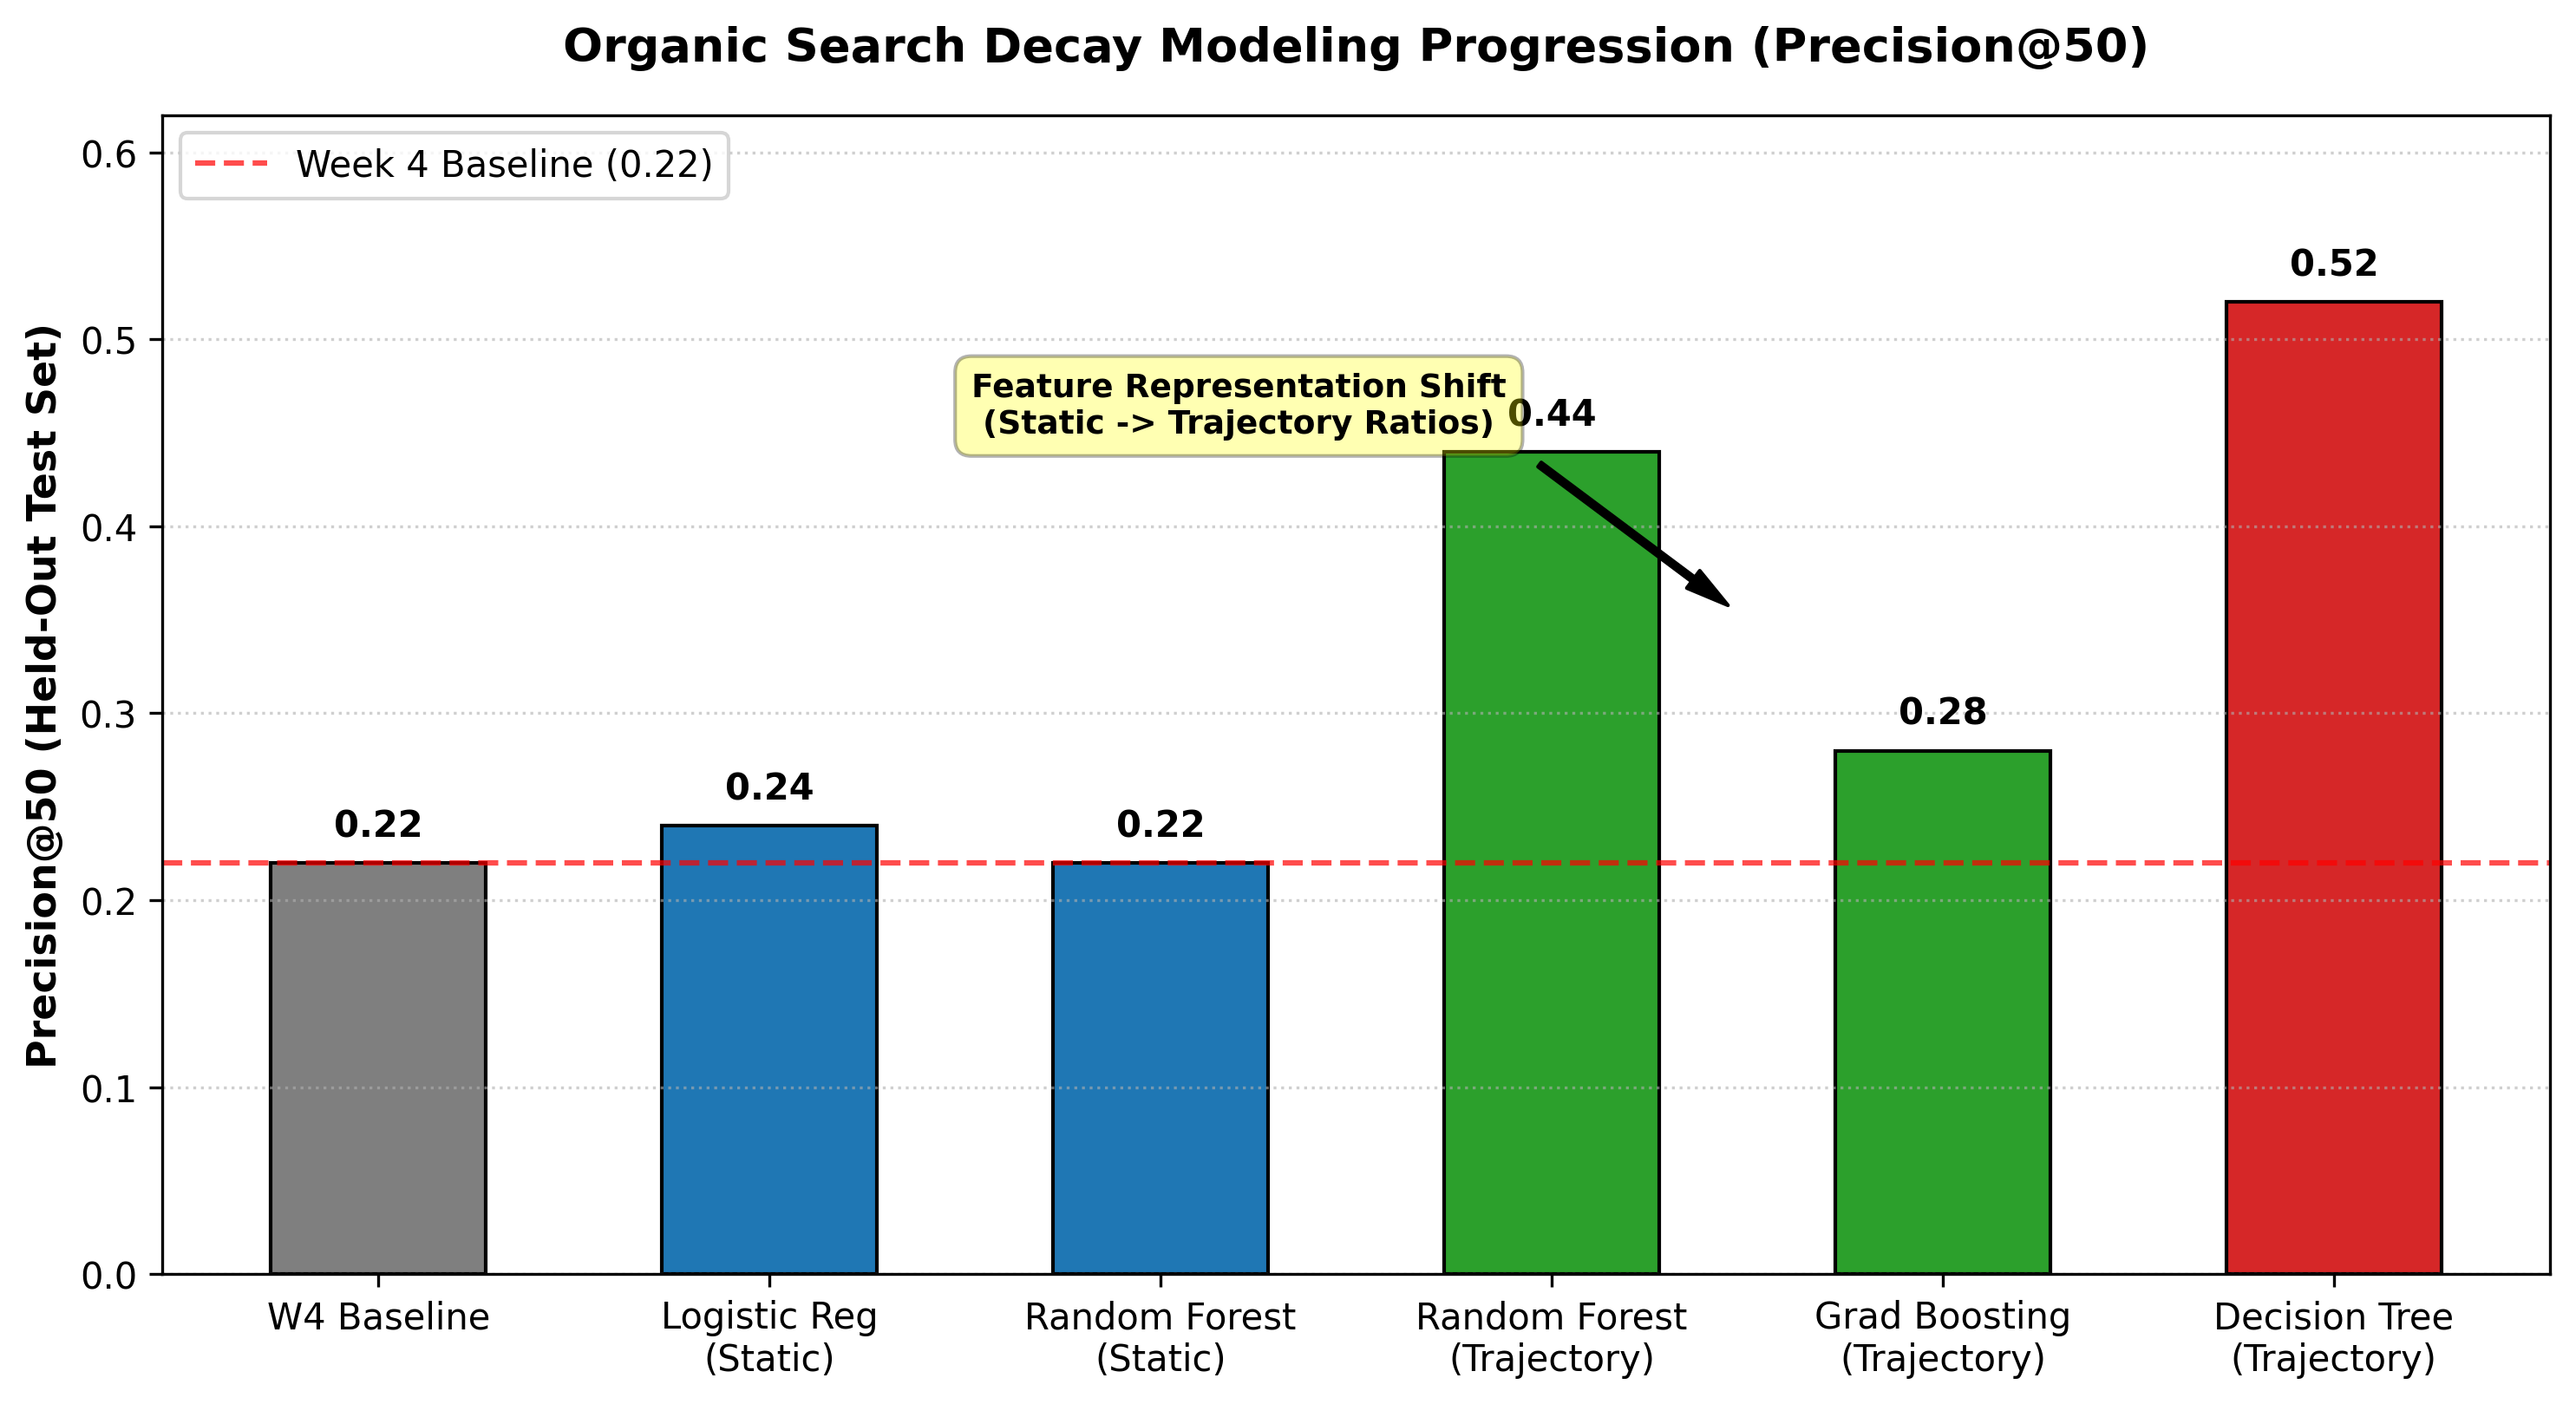

In [4]:
# -------------------------------------------------------------------------
# Cell 4: Executable Modeling Progression Chart
# -------------------------------------------------------------------------
plot_models = [
    'W4 Baseline',
    'Logistic Reg\n(Static)',
    'Random Forest\n(Static)',
    'Random Forest\n(Trajectory)',
    'Grad Boosting\n(Trajectory)',
    'Decision Tree\n(Trajectory)'
]
# Dynamically pull Precision@50 values from comp_df to ensure ZERO hardcoded metrics
p50_vals = [
    float(comp_df.loc[comp_df["Model"] == "Week 4 Heuristic Rule", "Precision@50"].values[0]),
    float(comp_df.loc[(comp_df["Model"] == "Logistic Regression") & (comp_df["Feature Set"] == "Static Totals"), "Precision@50"].values[0]),
    float(comp_df.loc[(comp_df["Model"] == "Random Forest") & (comp_df["Feature Set"] == "Static Totals"), "Precision@50"].values[0]),
    float(comp_df.loc[(comp_df["Model"] == "Random Forest") & (comp_df["Feature Set"] == "Trajectory & Ratios"), "Precision@50"].values[0]),
    float(comp_df.loc[(comp_df["Model"] == "Gradient Boosting") & (comp_df["Feature Set"] == "Trajectory & Ratios"), "Precision@50"].values[0]),
    float(comp_df.loc[(comp_df["Model"] == "Decision Tree (Depth=6)") & (comp_df["Feature Set"] == "Trajectory & Ratios"), "Precision@50"].values[0])
]

bar_colors = ['#7f7f7f', '#1f77b4', '#1f77b4', '#2ca02c', '#2ca02c', '#d62728']

plt.figure(figsize=(10, 5.5), dpi=300)
bars = plt.bar(plot_models, p50_vals, color=bar_colors, width=0.55, edgecolor='black', linewidth=1)
plt.axhline(p50_vals[0], color='red', linestyle='--', alpha=0.7, label=f'Week 4 Baseline ({p50_vals[0]:.2f})')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Organic Search Decay Modeling Progression (Precision@50)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Precision@50 (Held-Out Test Set)', fontsize=11, fontweight='bold')
plt.ylim(0, 0.62)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Annotate the trajectory feature shift
plt.annotate('Feature Representation Shift\n(Static -> Trajectory Ratios)',
             xy=(3.5, 0.35),
             xytext=(2.2, 0.45),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=6),
             fontsize=9, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 4. Diagnostics of the Candidate Decision Tree Model

We audit `DecisionTreeClassifier(max_depth=6)` to inspect its feature importances, ablation sensitivity, permutation importance, and multi-seed stability across held-out client splits.

The next cell executes feature importance audits, systematic feature ablation, multi-seed cross-validation across 5 client splits, and extracts the top decision rules.

In [5]:
# -------------------------------------------------------------------------
# Cell 5: Executable Diagnostic Audits
# -------------------------------------------------------------------------
# 1. Feature & Permutation Importance
def p50_scorer(estimator, X_eval, y_eval):
    scores = estimator.predict_proba(X_eval)[:, 1]
    eval_df = pd.DataFrame({"y": list(y_eval), "score": list(scores), "tie_breaker": list(ids_te)})
    top_k = eval_df.sort_values(["score", "tie_breaker"], ascending=[False, True]).head(min(50, len(eval_df)))
    return float(top_k["y"].mean())

perm_imp = permutation_importance(dt_traj, X_traj_te, y_te, scoring=p50_scorer, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    "Feature": trajectory_cols,
    "Permutation Importance Mean": perm_imp.importances_mean,
    "Tree Gini Importance": dt_traj.feature_importances_
}).sort_values("Permutation Importance Mean", ascending=False).reset_index(drop=True)

print("=== Feature & Permutation Importance Breakdown ===")
display(perm_df)

# 2. Systematic Ablation
ablation_experiments = {
    "Full Trajectory Model": trajectory_cols,
    "Without pos_delta": [c for c in trajectory_cols if c != "pos_delta"],
    "Without ctr_delta": [c for c in trajectory_cols if c != "ctr_delta"],
    "Without impr_ratio": [c for c in trajectory_cols if c != "impr_ratio_apr_vs_feb_mar"],
    "Without click_ratio": [c for c in trajectory_cols if c != "click_ratio_apr_vs_feb_mar"],
    "Without pv_ratio": [c for c in trajectory_cols if c != "pv_ratio_apr_vs_feb_mar"],
    "Without all trajectory features (Static Only)": static_cols
}
ablation_results = []
full_p50 = p50_dt_t
for exp_name, cols in ablation_experiments.items():
    dt_exp = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
    dt_exp.fit(modeling_df[cols].iloc[tr_42].astype(float), y_tr)
    exp_probs = dt_exp.predict_proba(modeling_df[cols].iloc[te_42].astype(float))[:, 1]
    exp_p50, exp_tp, exp_fp = precision_at_k(y_te, exp_probs, ids_te, k=50)
    ablation_results.append({
        "Experiment": exp_name,
        "Precision@50": f"{exp_p50:.4f}",
        "Delta vs Full Model": f"{exp_p50 - full_p50:+.4f}",
        "TP (Top 50)": exp_tp,
        "FP (Top 50)": exp_fp
    })
print("\n=== Systematic Feature Ablation Matrix ===")
display(pd.DataFrame(ablation_results))

# 3. Multi-Seed Robustness
seeds = [42, 101, 2024, 7, 99]
seed_results = []
for seed in seeds:
    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    tr_s, te_s = next(gss_s.split(modeling_df, y, groups=groups))
    y_tr_s, y_te_s = y.iloc[tr_s], y.iloc[te_s]
    ids_te_s = modeling_df["content_hash_id"].iloc[te_s]

    b_p50_s, _, _ = precision_at_k(y_te_s, modeling_df["baseline_score"].iloc[te_s], ids_te_s, k=50)

    lr_s = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))])
    lr_s.fit(modeling_df[static_cols].iloc[tr_s].astype(float), y_tr_s)
    lr_p50_s, _, _ = precision_at_k(y_te_s, lr_s.predict_proba(modeling_df[static_cols].iloc[te_s].astype(float))[:, 1], ids_te_s, k=50)

    dt_s = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42)
    dt_s.fit(modeling_df[trajectory_cols].iloc[tr_s].astype(float), y_tr_s)
    dt_p50_s, _, _ = precision_at_k(y_te_s, dt_s.predict_proba(modeling_df[trajectory_cols].iloc[te_s].astype(float))[:, 1], ids_te_s, k=50)

    gb_s = GradientBoostingClassifier(n_estimators=150, learning_rate=0.03, max_depth=4, subsample=0.8, random_state=42)
    gb_s.fit(modeling_df[trajectory_cols].iloc[tr_s].astype(float), y_tr_s)
    gb_p50_s, _, _ = precision_at_k(y_te_s, gb_s.predict_proba(modeling_df[trajectory_cols].iloc[te_s].astype(float))[:, 1], ids_te_s, k=50)

    seed_results.append({
        "Seed": seed,
        "W4 Baseline P@50": b_p50_s,
        "LR Static P@50": lr_p50_s,
        "DT Trajectory P@50": dt_p50_s,
        "GBDT Trajectory P@50": gb_p50_s
    })
seed_df = pd.DataFrame(seed_results)
summary_stats = pd.DataFrame([
    {"Approach": "W4 Baseline Rule", "Mean P@50": f"{seed_df['W4 Baseline P@50'].mean():.4f}", "Std Dev": f"{seed_df['W4 Baseline P@50'].std():.4f}", "Min P@50": f"{seed_df['W4 Baseline P@50'].min():.4f}", "Max P@50": f"{seed_df['W4 Baseline P@50'].max():.4f}"},
    {"Approach": "Logistic Regression (Static)", "Mean P@50": f"{seed_df['LR Static P@50'].mean():.4f}", "Std Dev": f"{seed_df['LR Static P@50'].std():.4f}", "Min P@50": f"{seed_df['LR Static P@50'].min():.4f}", "Max P@50": f"{seed_df['LR Static P@50'].max():.4f}"},
    {"Approach": "Decision Tree (Trajectory)", "Mean P@50": f"{seed_df['DT Trajectory P@50'].mean():.4f}", "Std Dev": f"{seed_df['DT Trajectory P@50'].std():.4f}", "Min P@50": f"{seed_df['DT Trajectory P@50'].min():.4f}", "Max P@50": f"{seed_df['DT Trajectory P@50'].max():.4f}"},
    {"Approach": "Gradient Boosting (Trajectory)", "Mean P@50": f"{seed_df['GBDT Trajectory P@50'].mean():.4f}", "Std Dev": f"{seed_df['GBDT Trajectory P@50'].std():.4f}", "Min P@50": f"{seed_df['GBDT Trajectory P@50'].min():.4f}", "Max P@50": f"{seed_df['GBDT Trajectory P@50'].max():.4f}"}
])
print("\n=== Multi-Seed Stability Summary across 5 Client Splits ===")
display(summary_stats)

# 4. Upper Tree Structure
print("\n=== Upper 3 Levels of Decision Tree Rules ===")
print(export_text(dt_traj, feature_names=trajectory_cols, max_depth=3))

=== Feature & Permutation Importance Breakdown ===


,Feature,Permutation Importance Mean,Tree Gini Importance
0,pv_ratio_apr_vs_feb_mar,0.110,0.047007
1,pos_delta,0.058,0.642213
2,ctr_delta,0.056,0.129537
3,gsc_avg_position_apr,0.046,0.027071
4,impr_ratio_apr_vs_feb_mar,0.024,0.078063
5,log_gsc_impressions_feb_apr,0.000,0.014172
6,log_gsc_clicks_apr,0.000,0.002169
7,ctr_apr,0.000,0.016142
8,client_has_ga4,0.000,0.000000
9,client_has_gsc,0.000,0.000000



=== Systematic Feature Ablation Matrix ===


,Experiment,Precision@50,Delta vs Full Model,TP (Top 50),FP (Top 50)
0,Full Trajectory Model,0.5200,+0.0000,26,24
1,Without pos_delta,0.4600,-0.0600,23,27
2,Without ctr_delta,0.4000,-0.1200,20,30
3,Without impr_ratio,0.4000,-0.1200,20,30
4,Without click_ratio,0.5200,+0.0000,26,24
5,Without pv_ratio,0.2600,-0.2600,13,37
6,Without all trajectory features (Static Only),0.5000,-0.0200,25,25



=== Multi-Seed Stability Summary across 5 Client Splits ===


,Approach,Mean P@50,Std Dev,Min P@50,Max P@50
0,W4 Baseline Rule,0.2400,0.0316,0.2000,0.2800
1,Logistic Regression (Static),0.2720,0.0901,0.1800,0.4200
2,Decision Tree (Trajectory),0.4800,0.0583,0.4200,0.5600
3,Gradient Boosting (Trajectory),0.3760,0.0684,0.2800,0.4400



=== Upper 3 Levels of Decision Tree Rules ===
|--- pos_delta <= -2.75
|   |--- pos_delta <= -2.75
|   |   |--- ctr_delta <= 0.00
|   |   |   |--- log_ga4_pageviews_feb_apr <= 4.56
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- log_ga4_pageviews_feb_apr >  4.56
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- ctr_delta >  0.00
|   |   |   |--- log_ga4_pageviews_feb_apr <= 6.10
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- log_ga4_pageviews_feb_apr >  6.10
|   |   |   |   |--- truncated branch of depth 2
|   |--- pos_delta >  -2.75
|   |   |--- class: 1
|--- pos_delta >  -2.75
|   |--- impr_ratio_apr_vs_feb_mar <= 76.41
|   |   |--- ctr_delta <= 0.00
|   |   |   |--- pos_delta <= 1.79
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- pos_delta >  1.79
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- ctr_delta >  0.00
|   |   |   |--- log_ga4_pageviews_feb_apr <= 5.43
|   |   |   |   |--- truncated branch of

## 5. Technical Recommendation & Next Steps

### 1. What did the Week 4 rule teach us?
The handwritten rule established an operational baseline (**Precision@50 = 0.2200**), showing that static daily thresholding identifies volume scale but lacks ranking accuracy.

### 2. What did Logistic Regression teach us?
Logistic Regression measured a minor improvement (**0.2400**), showing that continuous linear weighting of volume scale helps slightly, but linear log-odds assumptions cannot capture non-linear position rank boundaries.

### 3. What did tree models teach us?
In these experiments, the evaluated tree models captured non-linear decision boundaries that the Logistic Regression model could not represent. The exported tree includes splits such as `pos_delta <= -2.75`, illustrating this behavior.

### 4. Did algorithm complexity alone explain the improvement?
No. On static volume totals, moving from Logistic Regression to Random Forest or Gradient Boosting only shifted Precision@50 from **0.2400 to 0.2600–0.2800**.

### 5. Did feature engineering contribute more?
Yes. In these experiments, feature engineering produced larger measured improvements than changing algorithms alone. Introducing historical trajectory signals (`pv_ratio`, `ctr_delta`) lifted Decision Tree performance to **0.5200**.

### 6. Why is the candidate model recommended?
Based on these measured experiments, among the evaluated models, **Decision Tree** (`depth=6`) with **trajectory features** is the strongest candidate for further validation. It achieved the highest mean Precision@50 (**0.4800 $\pm$ 0.0583 across 5 client folds**) while remaining 100% human-interpretable (`export_text` rules can be audited directly by domain stakeholders).

### 7. What limitations still exist?
The evaluation relies on a single 90-day feature window (Feb–Apr 2026) and a 1-month target window (May 2026). Client group variance (0.42 to 0.56 across seeds) indicates sensitivity to specific enterprise client portfolios.

### 8. What is the next engineering step?
If this project continued into further engineering validation:
1. Evaluate **multi-month rolling slopes** (such as 3-month CTR linear regression slope) to capture longer-term trends.
2. Test a native pairwise ranking model like **LambdaMART (LightGBM Ranker)** that directly optimizes a top-K ranking objective.